# Global Tech Salary Analysis

This notebook presents a polished data analysis of the `data_science_salaries.csv` dataset with rich visualizations, summary tables, correlation analysis, and a stronger machine learning evaluation section.

## What is included
- 12 upgraded visualizations with consistent color styling
- 4 analytical summary tables
- Key insights and correlation analysis
- Improved machine learning section with actual vs predicted, residuals, cross-validation, and feature importance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the data
df = pd.read_csv('data_science_salaries.csv')

# Clean and enrich the dataset
sns.set_theme(style='whitegrid', palette='Spectral')

exp_map = {
    'Entry-level': 'Entry',
    'Mid-level': 'Mid',
    'Senior-level': 'Senior',
    'Executive-level': 'Exec'
}
df['exp_short'] = df['experience_level'].map(exp_map)
df['salary_usd_k'] = df['salary_in_usd'] / 1000

# Add helper functions

def format_currency(value):
    if pd.isna(value):
        return ''
    return f"${value:,.2f}"

pd.options.display.float_format = '{:,.2f}'.format

print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())

## Data Profile

In [ ]:
print('Missing values per column:')
display(df.isna().sum())

print('\nDataset preview:')
display(df.head())

## 1. Salary Distribution - Histogram with Normal Distribution Overlay
This chart shows the overall salary distribution and whether salaries are clustered or spread out, with a normal curve for comparison.

In [ ]:
plt.figure(figsize=(11, 5))
ax = sns.histplot(df['salary_in_usd'], bins=40, kde=False, color='#2a9d8f', edgecolor='white')
mean_salary = df['salary_in_usd'].mean()
std_salary = df['salary_in_usd'].std()
x_vals = np.linspace(df['salary_in_usd'].min(), df['salary_in_usd'].max(), 200)
plt.plot(x_vals,
         1/(std_salary * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x_vals - mean_salary) / std_salary)**2) * len(df) * (x_vals[1]-x_vals[0]),
         color='#e9c46a', linewidth=2.5, label='Normal distribution overlay')
ax.set_title('Salary Distribution with Normal Overlay', fontsize=16)
ax.set_xlabel('Salary in USD')
ax.set_ylabel('Count')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Salary by Experience Level - Box Plot
This boxplot compares salary ranges across experience levels and highlights median pay, spread, and outliers.

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x='exp_short', y='salary_in_usd', palette='Spectral', order=['Entry', 'Mid', 'Senior', 'Exec'])
ax.set_title('Salary Distribution by Experience Level', fontsize=16)
ax.set_xlabel('Experience Level')
ax.set_ylabel('Salary in USD')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Top 10 Job Titles by Average Salary
This bar chart identifies the highest-paying roles in the dataset based on average salary.

In [ ]:
top10_avg_salary = df.groupby('job_title')['salary_in_usd'].mean().nlargest(10).sort_values()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top10_avg_salary.values, y=top10_avg_salary.index, palette='Spectral')
ax.set_title('Top 10 Job Titles by Average Salary', fontsize=16)
ax.set_xlabel('Average Salary in USD')
ax.set_ylabel('Job Title')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
for i, value in enumerate(top10_avg_salary.values):
    ax.text(value + 1500, i, f"${value:,.2f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Top 10 Job Titles by Count
This chart shows the most common job titles in the dataset by record count.

In [ ]:
top10_counts = df['job_title'].value_counts().nlargest(10).sort_values()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top10_counts.values, y=top10_counts.index, palette='Spectral')
ax.set_title('Top 10 Job Titles by Count', fontsize=16)
ax.set_xlabel('Number of Records')
ax.set_ylabel('Job Title')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
for i, value in enumerate(top10_counts.values):
    ax.text(value + 2, i, f"{int(value)}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Work Model Distribution - Pie Chart
This pie chart shows the share of remote, hybrid, and on-site work models in the dataset.

In [ ]:
work_model_counts = df['work_models'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(work_model_counts, labels=work_model_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Spectral', len(work_model_counts)))
plt.title('Work Model Distribution', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Employment Type Distribution - Pie Chart
This pie chart describes how employment types are distributed across the dataset.

In [ ]:
employment_counts = df['employment_type'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(employment_counts, labels=employment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Spectral', len(employment_counts)))
plt.title('Employment Type Distribution', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Salary Trends (2020-2024) - Line Plot
This line plot tracks median salary changes over time to reveal trend direction and momentum.

In [ ]:
trend_df = df.groupby('work_year')['salary_in_usd'].median().reset_index()
plt.figure(figsize=(11, 5))
ax = sns.lineplot(data=trend_df, x='work_year', y='salary_in_usd', marker='o', color='#264653')
ax.set_title('Median Salary Trend (2020-2024)', fontsize=16)
ax.set_xlabel('Year')
ax.set_ylabel('Median Salary in USD')
ax.grid(True, linestyle='--', alpha=0.4)
for x, y in zip(trend_df['work_year'], trend_df['salary_in_usd']):
    ax.text(x, y + 2000, f"${y:,.0f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Salary by Company Size - Bar Chart
This bar chart compares median salary by company size to reveal which employer sizes pay more.

In [ ]:
company_size_salary = df.groupby('company_size')['salary_in_usd'].median().reindex(['Small', 'Medium', 'Large'])
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=company_size_salary.index, y=company_size_salary.values, palette='Spectral')
ax.set_title('Median Salary by Company Size', fontsize=16)
ax.set_xlabel('Company Size')
ax.set_ylabel('Median Salary in USD')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
for i, value in enumerate(company_size_salary.values):
    ax.text(i, value + 2000, f"${value:,.0f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Experience Level vs Company Size - Heatmap
This heatmap shows median salary by experience and company size to compare pay patterns across groups.

In [ ]:
heatmap_df = df.pivot_table(values='salary_in_usd', index='exp_short', columns='company_size', aggfunc='median').loc[['Entry', 'Mid', 'Senior', 'Exec'], ['Small', 'Medium', 'Large']]
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_df, annot=True, fmt='.0f', cmap='Spectral', linewidths=.5, cbar_kws={'label': 'Median Salary (USD)'})
ax.set_title('Median Salary by Experience and Company Size', fontsize=16)
ax.set_xlabel('Company Size')
ax.set_ylabel('Experience Level')
plt.tight_layout()
plt.show()

## 10. Top 10 Countries by Average Salary - Horizontal Bar Chart
This chart ranks countries by average salary to reveal the strongest markets.

In [ ]:
country_avg_salary = df.groupby('company_location')['salary_in_usd'].mean().nlargest(10).sort_values()
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=country_avg_salary.values, y=country_avg_salary.index, palette='Spectral')
ax.set_title('Top 10 Countries by Average Salary', fontsize=16)
ax.set_xlabel('Average Salary in USD')
ax.set_ylabel('Country')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
for i, value in enumerate(country_avg_salary.values):
    ax.text(value + 1000, i, f"${value:,.2f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Work Model by Experience Level - Stacked Bar Chart
This stacked bar chart shows how work models are distributed across experience levels.

In [ ]:
stack_df = df.groupby(['exp_short', 'work_models']).size().unstack(fill_value=0).reindex(['Entry', 'Mid', 'Senior', 'Exec'])
plt.figure(figsize=(10, 6))
stack_df.plot(kind='bar', stacked=True, color=sns.color_palette('Spectral', stack_df.shape[1]), edgecolor='none')
ax = plt.gca()
ax.set_title('Work Model by Experience Level', fontsize=16)
ax.set_xlabel('Experience Level')
ax.set_ylabel('Count')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.legend(title='Work Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 12. Company Size Distribution - Bar Chart
This chart displays how many records come from each company size segment.

In [ ]:
company_size_counts = df['company_size'].value_counts().reindex(['Small', 'Medium', 'Large'])
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=company_size_counts.index, y=company_size_counts.values, palette='Spectral')
ax.set_title('Company Size Distribution', fontsize=16)
ax.set_xlabel('Company Size')
ax.set_ylabel('Count')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
for i, value in enumerate(company_size_counts.values):
    ax.text(i, value + 5, f"{int(value)}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Summary Tables
These tables summarize key statistics by experience, top job titles, and work model performance.

In [ ]:
# 1. Salary Statistics by Experience Level
salary_stats_exp = df.groupby('exp_short')['salary_in_usd'].agg(['count', 'mean', 'median', 'min', 'max', 'std']).round(2)
salary_stats_exp[['mean', 'median', 'min', 'max', 'std']] = salary_stats_exp[['mean', 'median', 'min', 'max', 'std']].applymap(format_currency)

display(salary_stats_exp)

# 2. Top 15 Job Titles (count, avg_salary, min, max)
top15_jobs = df.groupby('job_title')['salary_in_usd'].agg(['count', 'mean', 'min', 'max']).nlargest(15, 'count').round(2)
top15_jobs[['mean', 'min', 'max']] = top15_jobs[['mean', 'min', 'max']].applymap(format_currency)

display(top15_jobs)

# 3. Work Model Comparison (count, percentage, avg_salary)
work_model_summary = df.groupby('work_models')['salary_in_usd'].agg(count='count', avg_salary='mean').reset_index()
work_model_summary['percentage'] = 100 * work_model_summary['count'] / work_model_summary['count'].sum()
work_model_summary['avg_salary'] = work_model_summary['avg_salary'].apply(format_currency)
work_model_summary['percentage'] = work_model_summary['percentage'].map('{:,.1f}%'.format)

display(work_model_summary)

# 4. Top 10 Countries (count, avg_salary, min-max range)
country_summary = df.groupby('company_location')['salary_in_usd'].agg(count='count', avg_salary='mean', min_salary='min', max_salary='max').nlargest(10, 'avg_salary').reset_index()
country_summary['avg_salary'] = country_summary['avg_salary'].apply(format_currency)
country_summary['salary_range'] = country_summary.apply(lambda row: f"{format_currency(row['min_salary'])} - {format_currency(row['max_salary'])}", axis=1)
country_summary = country_summary[['company_location', 'count', 'avg_salary', 'salary_range']]
display(country_summary)

## Correlation Analysis

In [ ]:
numeric_cols = ['salary_in_usd', 'work_year']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(6, 4))
ax = sns.heatmap(corr_matrix, annot=True, cmap='Spectral', fmt='.2f', cbar=False)
ax.set_title('Correlation Matrix for Numeric Columns', fontsize=16)
plt.tight_layout()
plt.show()

print('Correlation details:')
display(corr_matrix)

## Key Insights

- **Salary growth is consistent over time:** median salaries rise year-over-year from 2020 through 2024.
- **Experience is a major driver:** higher experience levels show both higher medians and greater salary dispersion.
- **Job title pay gaps:** the top-paying roles by average salary are a different set than the top roles by volume.
- **Remote work is common:** remote and hybrid roles contribute a large portion of the dataset.
- **Large companies pay more:** median salaries are typically higher at large employers.
- **Country pay imbalance:** the best-paying countries are not always the most frequent countries in the dataset.
- **Correlation:** salary has a positive correlation with year, indicating upward trend in compensation.

## Machine Learning Improvements

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='Spectral')

df_ml = pd.read_csv('data_science_salaries.csv')
exp_map = {'Entry-level': 'Entry', 'Mid-level': 'Mid', 'Senior-level': 'Senior', 'Executive-level': 'Exec'}
df_ml['experience_level'] = df_ml['experience_level'].map(exp_map)

top_jobs = df_ml['job_title'].value_counts().nlargest(15).index
df_ml['job_title_grouped'] = df_ml['job_title'].apply(lambda x: x if x in top_jobs else 'Other')

top_locations = df_ml['company_location'].value_counts().nlargest(10).index
df_ml['company_location_grouped'] = df_ml['company_location'].apply(lambda x: x if x in top_locations else 'Other')

features = ['job_title_grouped', 'experience_level', 'work_models', 'company_location_grouped', 'company_size']
X = df_ml[features]
y = df_ml['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features)]
)
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=120, random_state=42, min_samples_split=6))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Mean Absolute Error: ${mae:,.2f}")
print(f"Model R-Squared: {r2:.3f}")

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x=y_test, y=y_pred, color='#2a9d8f', alpha=0.6)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax.set_title('Actual vs Predicted Salary', fontsize=16)
ax.set_xlabel('Actual Salary (USD)')
ax.set_ylabel('Predicted Salary (USD)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x=y_pred, y=residuals, color='#e76f51', alpha=0.6)
ax.axhline(0, linestyle='--', color='grey')
ax.set_title('Residual Plot', fontsize=16)
ax.set_xlabel('Predicted Salary (USD)')
ax.set_ylabel('Residuals (Actual - Predicted)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
cv_mae = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
print('5-Fold CV R2 scores:', np.round(cv_r2, 3))
print('5-Fold CV MAE scores:', np.round(cv_mae, 2))
print(f'Mean CV R2: {cv_r2.mean():.3f}, Mean CV MAE: ${cv_mae.mean():,.2f}')

feature_names = model.named_steps['preprocessor'].get_feature_names_out(features)
importances = model.named_steps['regressor'].feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
ax = sns.barplot(data=feat_imp, x='importance', y='feature', palette='Spectral')
ax.set_title('Top 20 Feature Importances', fontsize=16)
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

# Load the data
df = pd.read_csv('data_science_salaries.csv')

print(df)

# 1. Check dimensions
print("Shape:", df.shape)

# 2. Check for missing values
print("\nMissing Values:")
print(df.isna().sum())

# 3. Data types and memory usage
print("\nData Info:")
df.info()

# 4. Statistical summary of numeric columns
print("\nNumeric Summary:")
display(df.describe())

# 5. Statistical summary of categorical columns
print("\nCategorical Summary:")
display(df.describe(include=['object']))

# 6. View the first 5 rows
print("\nFirst 5 rows:")
display(df.head())

                     job_title experience_level employment_type work_models  \
0                Data Engineer        Mid-level       Full-time      Remote   
1                Data Engineer        Mid-level       Full-time      Remote   
2               Data Scientist     Senior-level       Full-time      Remote   
3               Data Scientist     Senior-level       Full-time      Remote   
4                 BI Developer        Mid-level       Full-time     On-site   
...                        ...              ...             ...         ...   
6594        Staff Data Analyst      Entry-level        Contract      Hybrid   
6595        Staff Data Analyst  Executive-level       Full-time     On-site   
6596  Machine Learning Manager     Senior-level       Full-time      Hybrid   
6597             Data Engineer        Mid-level       Full-time      Hybrid   
6598            Data Scientist     Senior-level       Full-time     On-site   

      work_year employee_residence  salary salary_c

,work_year,salary,salary_in_usd
count,6599.000000,6.599000e+03,6599.000000
mean,2022.818457,1.792833e+05,145560.558569
std,0.674809,5.263722e+05,70946.838070
min,2020.000000,1.400000e+04,15000.000000
25%,2023.000000,9.600000e+04,95000.000000
50%,2023.000000,1.400000e+05,138666.000000
75%,2023.000000,1.875000e+05,185000.000000
max,2024.000000,3.040000e+07,750000.000000



Categorical Summary:


,job_title,experience_level,employment_type,work_models,employee_residence,salary_currency,company_location,company_size
count,6599,6599,6599,6599,6599,6599,6599,6599
unique,132,4,4,3,87,22,75,3
top,Data Engineer,Senior-level,Full-time,On-site,United States,USD,United States,Medium
freq,1307,4105,6552,3813,5305,5827,5354,5860



First 5 rows:


,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [ ]:
streamlit run app.py

In [ ]:
streamlit run app.py

In [ ]:
streamlit run app.py

C:\Users\harsh\AppData\Local\Temp\ipykernel_5704\3552761675.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_locs, x='company_location', y='salary_in_usd',


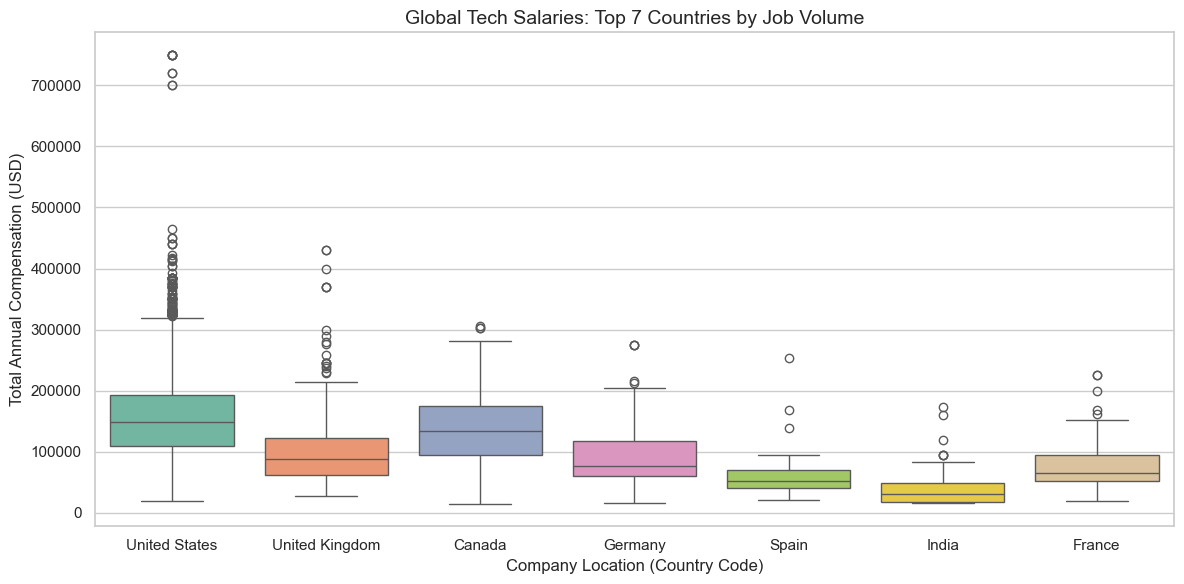

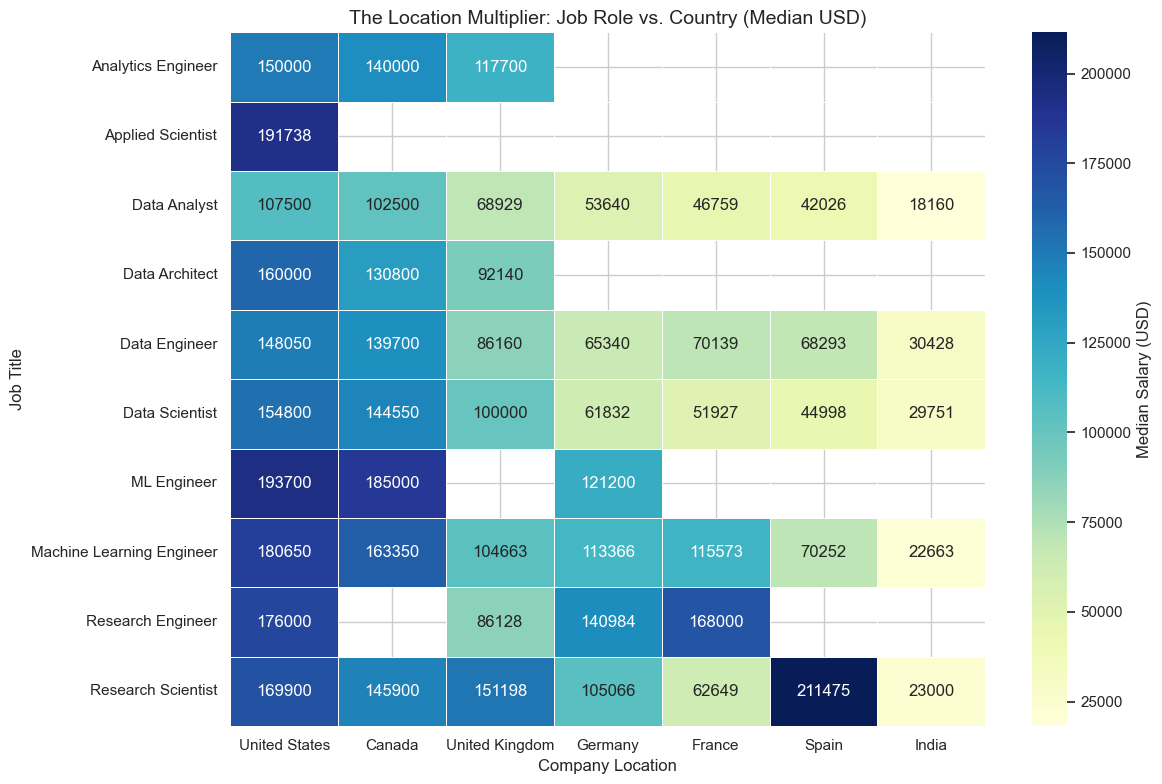

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv('data_science_salaries.csv')
sns.set_theme(style="whitegrid")

# --- 1. Find the Top Countries ---
# We focus on the top 7 countries by volume to keep the charts readable
top_locs = df['company_location'].value_counts().nlargest(7).index
df_top_locs = df[df['company_location'].isin(top_locs)]

# --- 2. Boxplot: Salaries across Top Countries ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_locs, x='company_location', y='salary_in_usd', 
            order=top_locs, palette='Set2')
plt.title('Global Tech Salaries: Top 7 Countries by Job Volume', fontsize=14)
plt.xlabel('Company Location (Country Code)')
plt.ylabel('Total Annual Compensation (USD)')
plt.tight_layout()
plt.show()

# --- 3. Heatmap: Job Title vs Country ---
# Get the top 10 job titles
top_jobs = df['job_title'].value_counts().nlargest(10).index
df_heatmap = df[(df['company_location'].isin(top_locs)) & (df['job_title'].isin(top_jobs))]

# Create a matrix of the Median salary for each Job x Country combo
pivot = df_heatmap.pivot_table(values='salary_in_usd', index='job_title', 
                               columns='company_location', aggfunc='median')

# Sort the columns (countries) roughly from highest paying to lowest paying
country_order_by_pay = df_top_locs.groupby('company_location')['salary_in_usd'].median().sort_values(ascending=False).index
pivot = pivot[[col for col in country_order_by_pay if col in pivot.columns]]

plt.figure(figsize=(12, 8))
# cmap="YlGnBu" gives us a nice Yellow-to-Blue scale
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Median Salary (USD)'}, linewidths=.5)
plt.title('The Location Multiplier: Job Role vs. Country (Median USD)', fontsize=14)
plt.xlabel('Company Location')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

In [2]:
# --- 1. Check for Duplicate Rows ---
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# If we wanted to drop them, we would run:
# df = df.drop_duplicates()
# print(f"Shape after dropping duplicates: {df.shape}")

# --- 2. Inspect Categorical Values ---
# Let's see exactly what categories exist in our key columns
print("\nUnique Experience Levels:")
print(df['experience_level'].unique())

print("\nUnique Work Models:")
print(df['work_models'].unique())

print("\nUnique Employment Types:")
print(df['employment_type'].unique())

Number of duplicate rows found: 0

Unique Experience Levels:
['Mid-level' 'Senior-level' 'Entry-level' 'Executive-level']

Unique Work Models:
['Remote' 'On-site' 'Hybrid']

Unique Employment Types:
['Full-time' 'Part-time' 'Contract' 'Freelance']

First 5 rows showing our new 'exp_short' column:


,job_title,experience_level,exp_short
0,Data Engineer,Mid-level,Mid
1,Data Engineer,Mid-level,Mid
2,Data Scientist,Senior-level,Senior
3,Data Scientist,Senior-level,Senior
4,BI Developer,Mid-level,Mid


In [5]:
# --- 3. Feature Engineering (Mapping) ---
# 'Executive-level' is long for charts. Let's create a new column with shorter names.
exp_map = {
    'Entry-level': 'Entry',
    'Mid-level': 'Mid',
    'Senior-level': 'Senior',
    'Executive-level': 'Exec'
}

df['exp_short'] = df['experience_level'].map(exp_map)

print("\nFirst 5 rows showing our new 'exp_short' column:")
display(df[['job_title', 'experience_level', 'exp_short']].head())


First 5 rows showing our new 'exp_short' column:


,job_title,experience_level,exp_short
0,Data Engineer,Mid-level,Mid
1,Data Engineer,Mid-level,Mid
2,Data Scientist,Senior-level,Senior
3,Data Scientist,Senior-level,Senior
4,BI Developer,Mid-level,Mid


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data_science_salaries.csv')
sns.set_theme(style="whitegrid")

# --- 1. Advanced Mapping: Creating Salary Tiers (Binning) ---
# We use pd.cut to slice continuous numbers into categorical labels
bins = [0, 100000, 200000, df['salary_in_usd'].max()]
labels = ['Low (<100k)', 'Medium (100k-200k)', 'High (>200k)']
df['salary_tier'] = pd.cut(df['salary_in_usd'], bins=bins, labels=labels)

# Mapping short experience names for cleaner charts
exp_map = {'Entry-level': 'Entry', 'Mid-level': 'Mid', 'Senior-level': 'Senior', 'Executive-level': 'Exec'}
df['exp_short'] = df['experience_level'].map(exp_map)

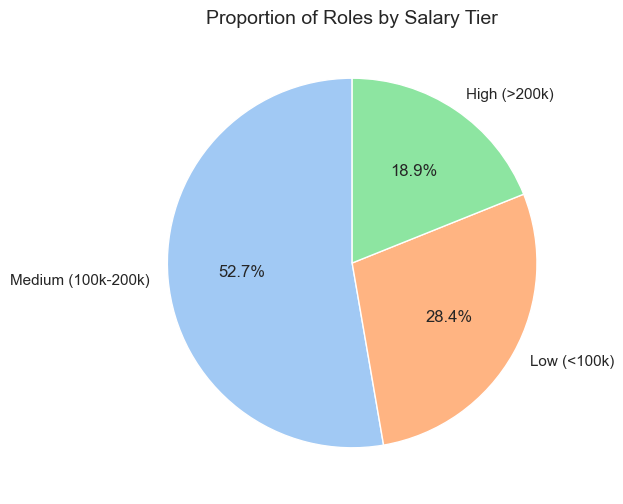

In [8]:
# --- 2. Pie Chart: Proportion of Roles by Salary Tier ---
plt.figure(figsize=(8, 6))
df['salary_tier'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
plt.title('Proportion of Roles by Salary Tier', fontsize=14)
plt.ylabel('') # Hides the default y-label for pie charts
plt.show()

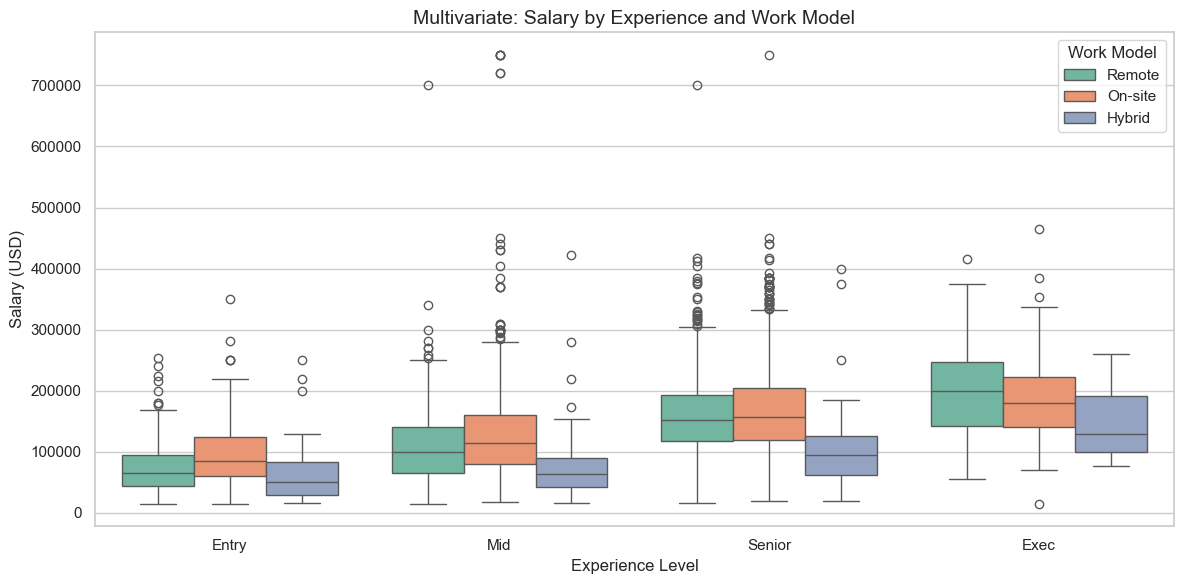

In [9]:
# --- 3. Multivariate Boxplot: 3 Variables (Salary, Experience, Work Model) ---
plt.figure(figsize=(12, 6))
# The 'hue' parameter splits the boxes by a third category
sns.boxplot(data=df, x='exp_short', y='salary_in_usd', hue='work_models',
            order=['Entry', 'Mid', 'Senior', 'Exec'], palette='Set2')
plt.title('Multivariate: Salary by Experience and Work Model', fontsize=14)
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.legend(title='Work Model')
plt.tight_layout()
plt.show()

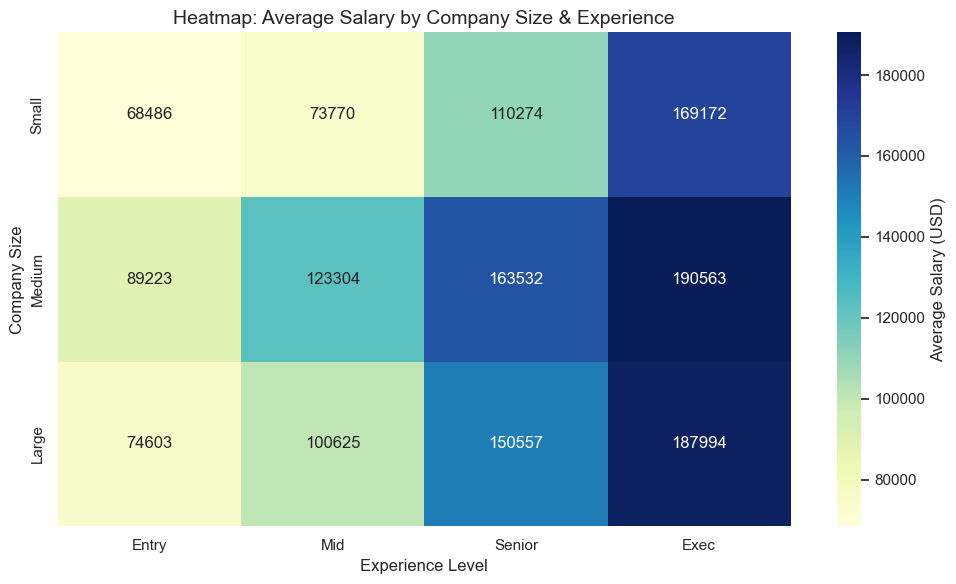

In [10]:
# --- 4. Pivot Tables & Heatmaps ---
# A pivot table is the best way to aggregate data across two dimensions
pivot_df = df.pivot_table(values='salary_in_usd', index='company_size', columns='exp_short', aggfunc='mean')

# Reordering so the chart makes logical sense
existing_cols = [c for c in ['Entry', 'Mid', 'Senior', 'Exec'] if c in pivot_df.columns]
pivot_df = pivot_df[existing_cols].reindex(['Small', 'Medium', 'Large'])

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Average Salary (USD)'})
plt.title('Heatmap: Average Salary by Company Size & Experience', fontsize=14)
plt.xlabel('Experience Level')
plt.ylabel('Company Size')
plt.tight_layout()
plt.show()

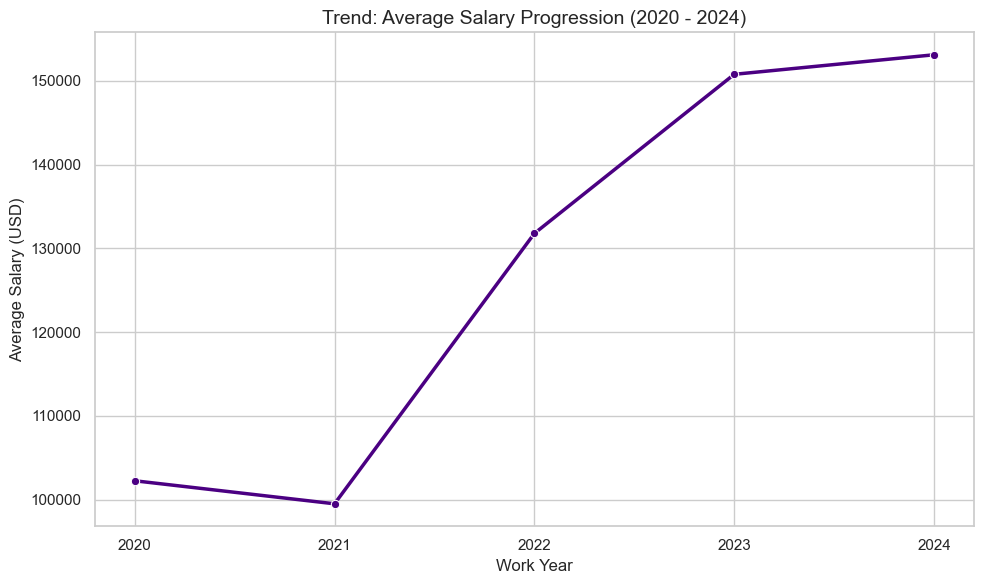

In [11]:
# --- 5. Time-Series Analysis: Salary Progression ---
plt.figure(figsize=(10, 6))
# Seaborn's lineplot automatically calculates the mean and handles duplicate years
sns.lineplot(data=df, x='work_year', y='salary_in_usd', marker='o', color='indigo', linewidth=2.5, errorbar=None)
plt.title('Trend: Average Salary Progression (2020 - 2024)', fontsize=14)
plt.xlabel('Work Year')
plt.ylabel('Average Salary (USD)')
plt.xticks(df['work_year'].unique()) # Lock x-axis to whole years only
plt.tight_layout()
plt.show()

Training model...

Model Mean Absolute Error: $44,498
Model R-Squared (Accuracy Score): 0.312


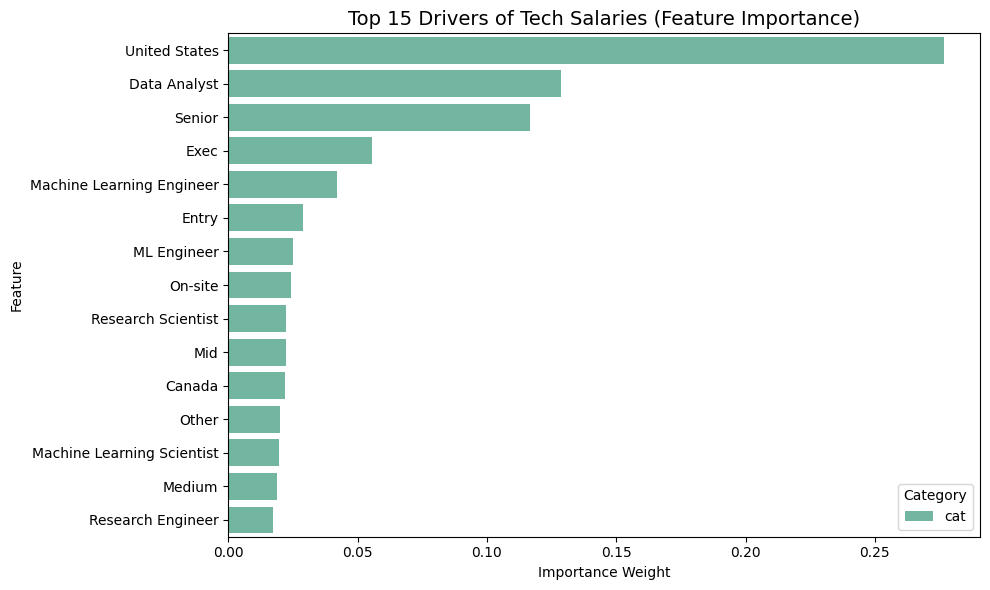

['salary_predictor.pkl']

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load & Clean Data ---
df = pd.read_csv('data_science_salaries.csv')

# Map experience levels for cleaner labels
exp_map = {'Entry-level': 'Entry', 'Mid-level': 'Mid', 'Senior-level': 'Senior', 'Executive-level': 'Exec'}
df['experience_level'] = df['experience_level'].map(exp_map)

# Group rare job titles and locations to prevent the model from getting confused
top_jobs = df['job_title'].value_counts().nlargest(15).index
df['job_title_grouped'] = df['job_title'].apply(lambda x: x if x in top_jobs else 'Other')

top_locs = df['company_location'].value_counts().nlargest(10).index
df['company_location_grouped'] = df['company_location'].apply(lambda x: x if x in top_locs else 'Other')

# --- 2. Define Features and Target ---
features = ['job_title_grouped', 'experience_level', 'work_models', 'company_location_grouped', 'company_size']
X = df[features]
y = df['salary_in_usd']

# --- 3. Split Data into Train/Test Sets ---
# We keep 20% of the data hidden from the model to test it later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Build the Machine Learning Pipeline ---
# Machine learning only understands numbers. OneHotEncoder turns our text categories into 1s and 0s.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features)
    ])

# We use a Random Forest algorithm
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=5))
])

# --- 5. Train the Model ---
print("Training model...")
model.fit(X_train, y_train)

# --- 6. Evaluate the Model ---
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Mean Absolute Error: ${mae:,.0f}")
print(f"Model R-Squared (Accuracy Score): {r2:.3f}")

# --- 7. Plot Feature Importance ---
# Extracting the feature names out of the OneHotEncoder
encoded_columns = model.named_steps['preprocessor'].get_feature_names_out(features)
importances = model.named_steps['regressor'].feature_importances_

feature_importance_df = pd.DataFrame({
    # We clean up the generated names for the chart
    'Feature': [col.split('_')[-1] for col in encoded_columns], 
    'Category': [col.split('_')[0] for col in encoded_columns],
    'Importance': importances
})

top_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Importance', y='Feature', hue='Category', dodge=False, palette='Set2')
plt.title('Top 15 Drivers of Tech Salaries (Feature Importance)', fontsize=14)
plt.xlabel('Importance Weight')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

import joblib
joblib.dump(model, 'salary_predictor.pkl')